# Iris Classification Project

## Objective
Build a classification model to predict iris species using sepal and petal measurements.

### Algorithms Used
- K-Nearest Neighbors (KNN)
- Logistic Regression
- Decision Tree

### Evaluation Metrics
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import joblib

print("Libraries Imported Successfully")

Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully


In [2]:
import os

print(os.getcwd())
print(os.listdir())

/Users/vidhi/Desktop/alfido-tech-internship/Task-1 Iris Classification
['.ipynb_checkpoints', 'Task-1 Iris Classification.ipynb']


In [3]:
import os
print(os.listdir())

['IRIS.csv', '.ipynb_checkpoints', 'Task-1 Iris Classification.ipynb']


In [4]:
import pandas as pd

df = pd.read_csv("IRIS.csv")

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

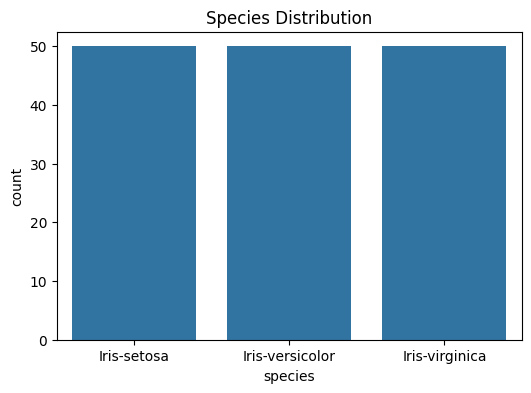

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='species', data=df)

plt.title("Species Distribution")

plt.show()

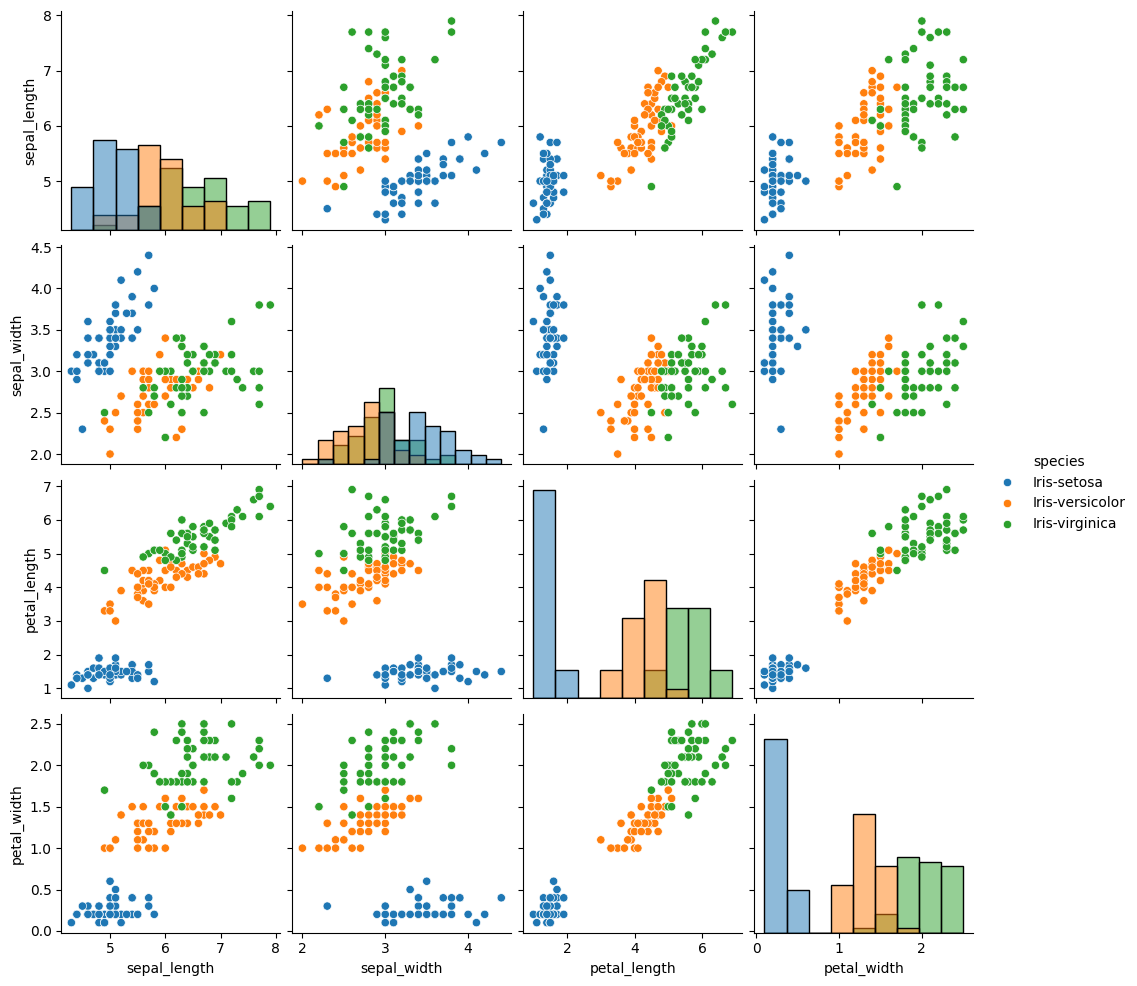

In [9]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.show()

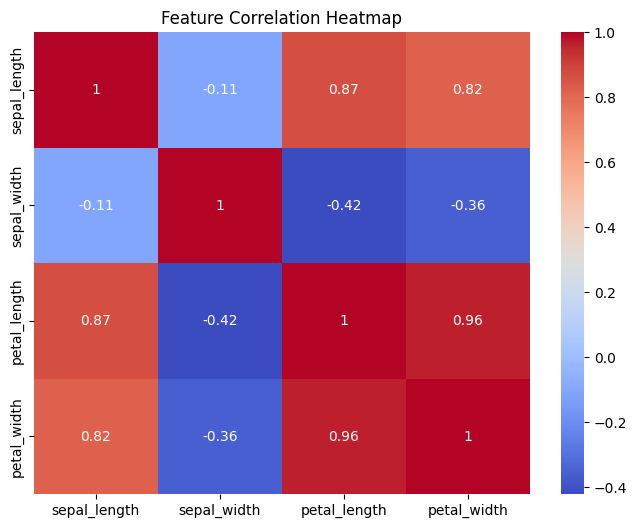

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

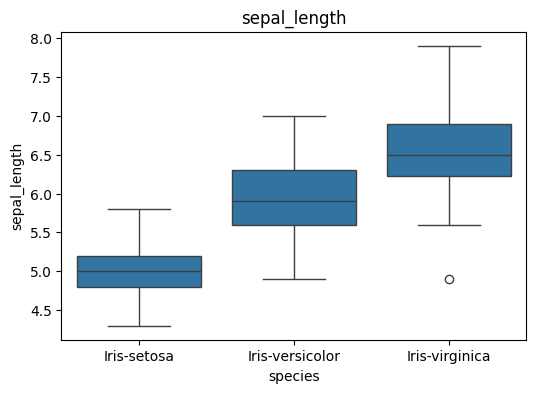

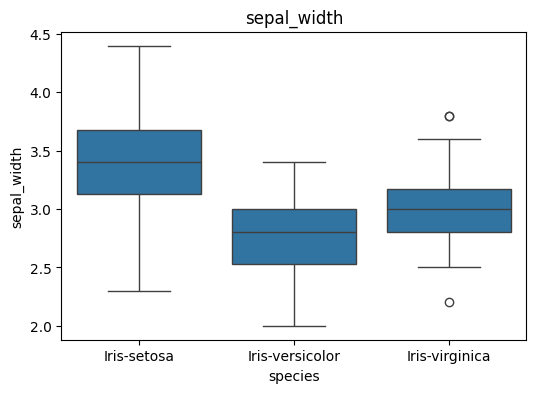

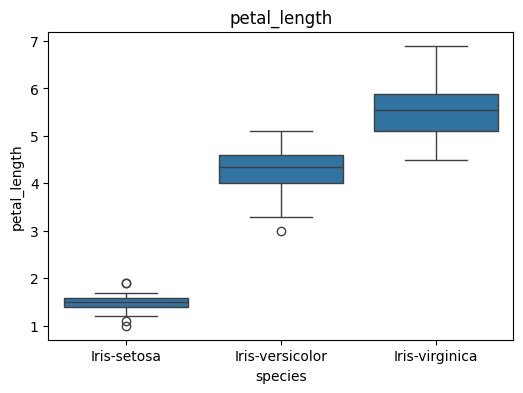

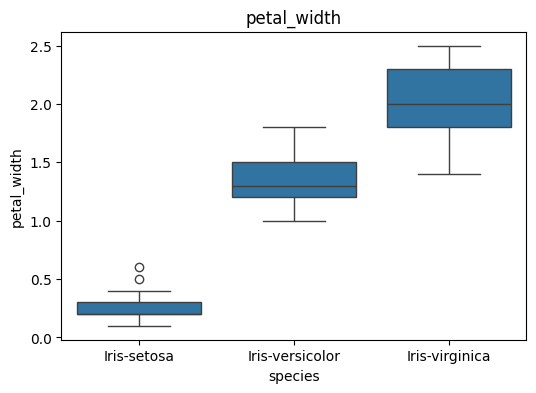

In [11]:
features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

for col in features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x="species",
        y=col,
        data=df
    )

    plt.title(col)

    plt.show()

In [12]:
X = df.drop("species", axis=1)
y = df["species"]

print(X.shape)
print(y.shape)

(150, 4)
(150,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (120, 4)
Testing Data: (30, 4)


In [14]:
models = {
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=200))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    )
}

In [15]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print("="*50)
    print(name)

    print("\nAccuracy:")
    print(accuracy)

    print("\nClassification Report:")
    print(classification_report(y_test, predictions))

KNN

Accuracy:
0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

Logistic Regression

Accuracy:
0.9333333333333333

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Decision Tree

Accuracy:
0.9333333333333333

Classification Repo

In [16]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
0,KNN,0.933333
1,Logistic Regression,0.933333
2,Decision Tree,0.933333


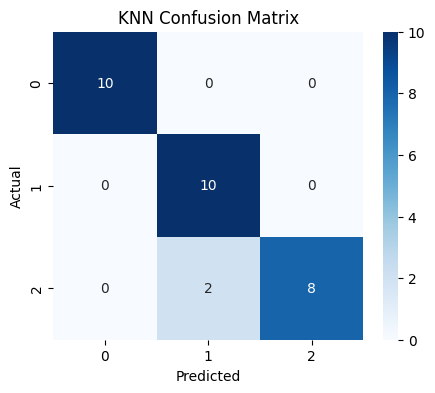

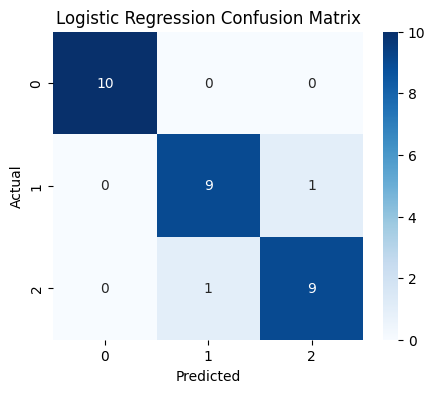

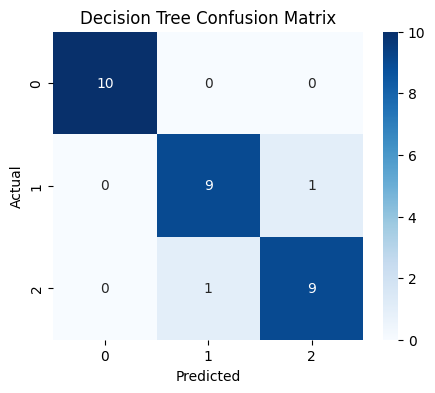

In [17]:
for name, model in models.items():

    predictions = model.predict(X_test)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [18]:
best_model = models["Logistic Regression"]

joblib.dump(
    best_model,
    "iris_best_model.joblib"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
loaded_model = joblib.load(
    "iris_best_model.joblib"
)

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = loaded_model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa


/Users/vidhi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
loaded_model = joblib.load("iris_best_model.joblib")

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

prediction = loaded_model.predict(sample)

print("Predicted Species:", prediction[0])

Predicted Species: Iris-setosa
